# Step 1: Load Cleaned Data and Saved Baseline Model

This notebook continues from preprocessing and baseline model training. The cleaned dataset is used because the raw files inside `data/raw/` should remain unchanged.

The saved baseline model is loaded from `models/baseline_price_model.joblib`. The model predicts `price`, so this is still a regression problem.

This project is a learning simulation for estimating online transportation fare. It is not a real production pricing system.


In [1]:
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
elif not (project_root / "data").exists():
    project_root = project_root.parent

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from preprocessing import create_time_features, get_feature_target
from evaluate_model import (
    calculate_regression_metrics,
    create_ct_checklist,
    create_prediction_result_dataframe,
    evaluate_by_group,
    save_report,
)
from data_validation import run_all_validations

cleaned_data_path = project_root / "data" / "processed" / "cleaned_cab_rides.csv"
model_path = project_root / "models" / "baseline_price_model.joblib"
model_report_path = project_root / "reports" / "model_evaluation_report.md"
quality_checklist_path = project_root / "reports" / "quality_checklist.md"

print("Project root:", project_root)
print("Cleaned data path:", cleaned_data_path)
print("Model path:", model_path)


Project root: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online
Cleaned data path: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online\data\processed\cleaned_cab_rides.csv
Model path: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online\models\baseline_price_model.joblib


In [2]:
cleaned_cab_rides = pd.read_csv(cleaned_data_path)
baseline_model = joblib.load(model_path)

print("Cleaned dataset shape:", cleaned_cab_rides.shape)
print("Loaded model type:", type(baseline_model).__name__)
display(cleaned_cab_rides.head())


Cleaned dataset shape: (637976, 10)
Loaded model type: Pipeline


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [3]:
invalid_datetime_rows = pd.to_datetime(
    cleaned_cab_rides["time_stamp"],
    unit="ms",
    errors="coerce",
).isna().sum()

model_data = create_time_features(cleaned_cab_rides)
X, y, feature_columns, numeric_features, categorical_features = get_feature_target(
    model_data,
    include_surge=False,
)
target_column = "price"

print("Invalid datetime rows dropped by time feature step:", invalid_datetime_rows)
print("Selected feature columns:")
for feature in feature_columns:
    print("-", feature)
print("Target column:", target_column)
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)


Invalid datetime rows dropped by time feature step: 0
Selected feature columns:
- distance
- cab_type
- source
- destination
- name
- hour
- day
- month
- day_of_week
Target column: price
Numerical features: ['distance', 'hour', 'day', 'month', 'day_of_week']
Categorical features: ['cab_type', 'source', 'destination', 'name']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

y_pred = baseline_model.predict(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Prediction shape:", y_pred.shape)
print("Model runs successfully:", len(y_pred) == len(y_test))


Train shape: (510380, 9)
Test shape: (127596, 9)
Prediction shape: (127596,)
Model runs successfully: True


# Step 2: Overall Regression Evaluation

Regression models are evaluated using numerical error metrics.

- MAE shows the average absolute prediction error.
- RMSE penalizes larger errors more heavily.
- R2 Score shows how much variance is explained by the model.

These metrics can later become part of the Continuous Training (CT) checklist.


In [5]:
metrics = calculate_regression_metrics(y_test, y_pred)
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score", "Mean Actual Price", "Median Actual Price"],
    "Value": [
        metrics["MAE"],
        metrics["RMSE"],
        metrics["R2 Score"],
        metrics["Mean Actual Price"],
        metrics["Median Actual Price"],
    ],
})

display(metrics_df)

mae_vs_mean_pct = metrics["MAE"] / metrics["Mean Actual Price"] * 100
mae_vs_median_pct = metrics["MAE"] / metrics["Median Actual Price"] * 100

print(f"MAE compared with mean actual price: {mae_vs_mean_pct:.2f}%")
print(f"MAE compared with median actual price: {mae_vs_median_pct:.2f}%")


,Metric,Value
0,MAE,1.425413
1,RMSE,2.618088
2,R2 Score,0.921377
3,Mean Actual Price,16.542276
4,Median Actual Price,13.500000


MAE compared with mean actual price: 8.62%
MAE compared with median actual price: 10.56%


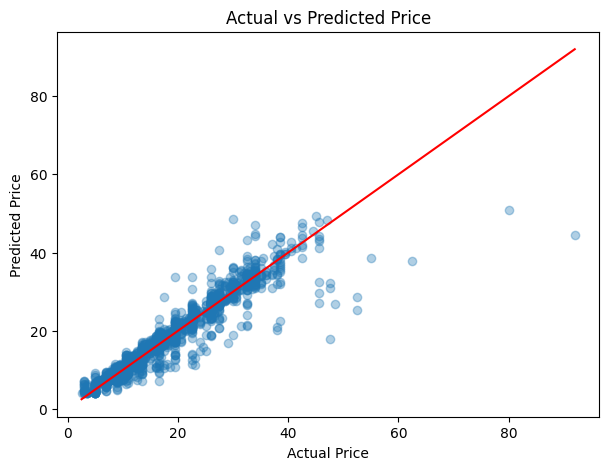

In [6]:
plot_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
actual_sample = y_test.loc[plot_sample.index]
predicted_sample = baseline_model.predict(plot_sample)

plt.figure(figsize=(7, 5))
plt.scatter(actual_sample, predicted_sample, alpha=0.35)
plt.plot(
    [actual_sample.min(), actual_sample.max()],
    [actual_sample.min(), actual_sample.max()],
    color="red",
)
plt.title("Actual vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()


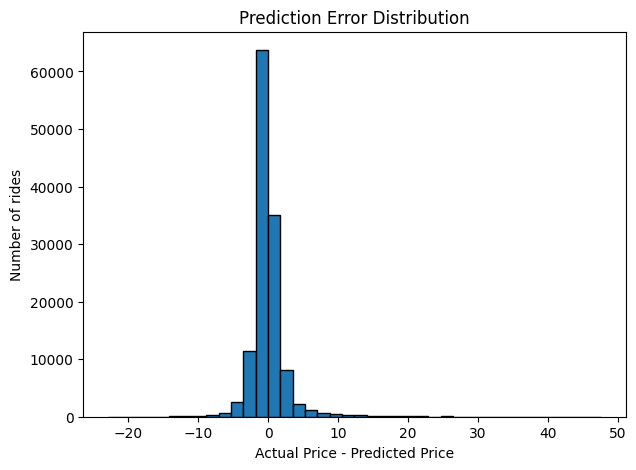

In [7]:
prediction_errors = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.hist(prediction_errors, bins=40, edgecolor="black")
plt.title("Prediction Error Distribution")
plt.xlabel("Actual Price - Predicted Price")
plt.ylabel("Number of rides")
plt.show()


# Step 3: Error Analysis by Trip Groups

A good model should not only perform well overall. The model should also be reviewed across different trip groups.

This supports the CT checklist for robustness and fairness-like quality review. In this project, fairness means stable prediction error across reasonable business groups, not sensitive personal attributes.


In [8]:
result_df = create_prediction_result_dataframe(X_test, y_test, y_pred)

result_df["distance_group"] = pd.qcut(
    result_df["distance"],
    q=3,
    labels=["short trip", "medium trip", "long trip"],
)

selected_result_columns = [
    "actual_price",
    "predicted_price",
    "absolute_error",
    "distance",
    "distance_group",
    "cab_type",
    "source",
    "destination",
    "name",
]

display(result_df[selected_result_columns].head())


,actual_price,predicted_price,absolute_error,distance,distance_group,cab_type,source,destination,name
484718,7.0,8.828376,1.828376,4.51,long trip,Lyft,Financial District,Fenway,Shared
466257,10.5,10.620882,0.120882,2.80,long trip,Uber,West End,Boston University,WAV
128490,7.0,7.579107,0.579107,1.09,short trip,Lyft,South Station,Theatre District,Lyft
216568,15.5,15.728474,0.228474,0.92,short trip,Uber,Financial District,Haymarket Square,Black
129302,16.5,16.690904,0.190904,1.12,short trip,Lyft,North End,North Station,Lux Black


In [9]:
distance_error = evaluate_by_group(result_df, "distance_group")
cab_type_error = evaluate_by_group(result_df, "cab_type")
name_error = evaluate_by_group(result_df, "name")
source_error = evaluate_by_group(result_df, "source")
destination_error = evaluate_by_group(result_df, "destination")

print("Error by distance group:")
display(distance_error)

print("Error by cab type:")
display(cab_type_error)

print("Error by ride service name:")
display(name_error)


Error by distance group:


,distance_group,row_count,MAE,RMSE
2,long trip,42101,1.828477,3.342571
1,medium trip,42552,1.484566,2.510905
0,short trip,42943,0.971639,1.779153


Error by cab type:


,cab_type,row_count,MAE,RMSE
0,Lyft,61339,1.672348,3.193459
1,Uber,66257,1.196807,1.938758


Error by ride service name:


,name,row_count,MAE,RMSE
4,Lux Black XL,10183,2.913570,5.303745
3,Lux Black,10378,2.022643,3.648355
2,Lux,10181,1.624340,2.888011
10,UberXL,11064,1.576041,2.688481
6,Lyft XL,10204,1.508761,2.596457
1,Black SUV,10966,1.412649,2.196520
0,Black,11019,1.248186,1.863059
7,Shared,10299,1.091411,1.555270
9,UberX,11107,0.992270,1.590553
11,WAV,11146,0.984789,1.558071


In [10]:
print("Top source groups by MAE:")
display(source_error.head(10))

print("Top destination groups by MAE:")
display(destination_error.head(10))


Top source groups by MAE:


,source,row_count,MAE,RMSE
3,Fenway,10727,1.868104,3.347889
8,Northeastern University,10665,1.838689,3.192946
0,Back Bay,10683,1.777021,3.204087
2,Boston University,10658,1.724704,3.239210
10,Theatre District,10417,1.654135,3.064359
4,Financial District,10818,1.475980,2.938993
1,Beacon Hill,10571,1.430087,2.478363
9,South Station,10467,1.327857,2.294188
7,North Station,10464,1.083191,1.828975
11,West End,10657,1.069658,1.771055


Top destination groups by MAE:


,destination,row_count,MAE,RMSE
2,Boston University,10551,1.638209,3.077739
8,Northeastern University,10723,1.585850,2.725764
4,Financial District,10798,1.551509,3.155174
3,Fenway,10696,1.535452,2.703981
0,Back Bay,10930,1.438725,2.406136
7,North Station,10476,1.428070,2.730897
10,Theatre District,10544,1.424014,2.476603
1,Beacon Hill,10696,1.400279,2.363386
11,West End,10542,1.367146,2.520606
6,North End,10541,1.281784,2.456768


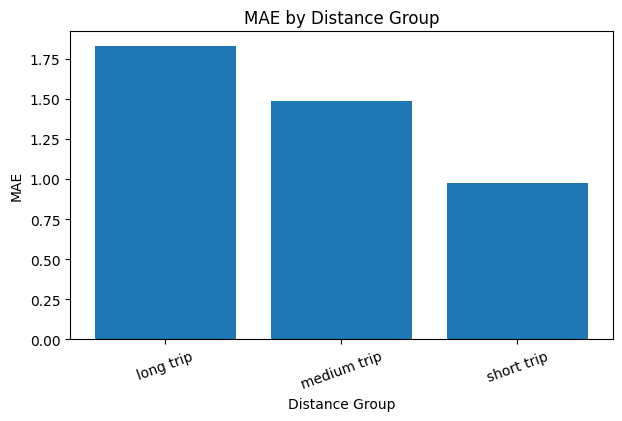

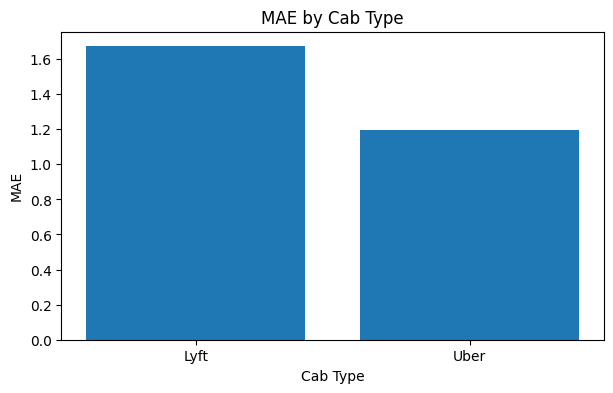

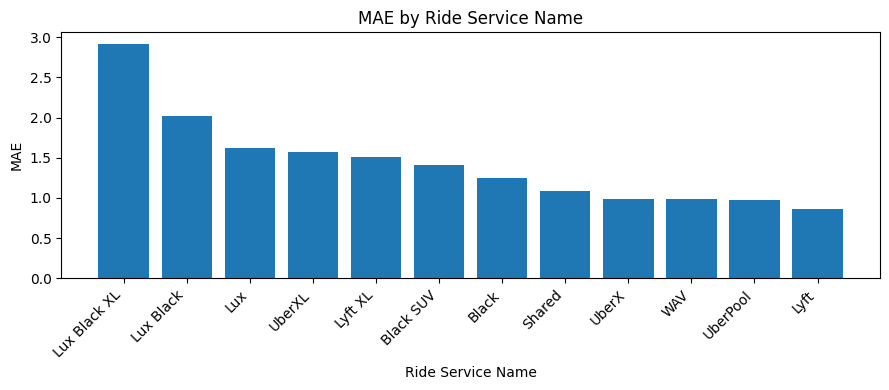

In [11]:
plt.figure(figsize=(7, 4))
plt.bar(distance_error["distance_group"].astype(str), distance_error["MAE"])
plt.title("MAE by Distance Group")
plt.xlabel("Distance Group")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(cab_type_error["cab_type"].astype(str), cab_type_error["MAE"])
plt.title("MAE by Cab Type")
plt.xlabel("Cab Type")
plt.ylabel("MAE")
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(name_error["name"].astype(str), name_error["MAE"])
plt.title("MAE by Ride Service Name")
plt.xlabel("Ride Service Name")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [12]:
group_tables = {
    "distance_group": distance_error,
    "cab_type": cab_type_error,
    "name": name_error,
    "source": source_error,
    "destination": destination_error,
}

highest_error_candidates = []
for group_name, table in group_tables.items():
    top_row = table.sort_values("MAE", ascending=False).iloc[0]
    group_value = top_row[group_name]
    highest_error_candidates.append({
        "Group Type": group_name,
        "Group Value": str(group_value),
        "MAE": float(top_row["MAE"]),
        "RMSE": float(top_row["RMSE"]),
        "Row Count": int(top_row["row_count"]),
    })

highest_error_summary = pd.DataFrame(highest_error_candidates).sort_values("MAE", ascending=False)
highest_error_group = highest_error_summary.iloc[0]

display(highest_error_summary)
print(
    "Highest error group:",
    f"{highest_error_group['Group Type']} = {highest_error_group['Group Value']}",
    f"with MAE {highest_error_group['MAE']:.4f}.",
)
print("Short interpretation: this group should be reviewed in the next feature engineering step because its average error is higher than other groups.")


,Group Type,Group Value,MAE,RMSE,Row Count
2,name,Lux Black XL,2.913570,5.303745,10183
3,source,Fenway,1.868104,3.347889,10727
0,distance_group,long trip,1.828477,3.342571,42101
1,cab_type,Lyft,1.672348,3.193459,61339
4,destination,Boston University,1.638209,3.077739,10551


Highest error group: name = Lux Black XL with MAE 2.9136.
Short interpretation: this group should be reviewed in the next feature engineering step because its average error is higher than other groups.


# Step 4: Data Validation and CI Checklist

CI in this project means checking whether code, data, and preprocessing are safe before training.

Data validation helps prevent invalid data from entering the training pipeline. The CI checklist comes from findings in Step 1 and Step 2, such as missing target values, invalid distances, invalid prices, missing categorical columns, invalid timestamps, and duplicate rows.


In [13]:
ci_checklist = run_all_validations(cleaned_cab_rides)
display(ci_checklist)

ci_status_summary = ci_checklist["Status"].value_counts().rename_axis("Status").reset_index(name="Count")
display(ci_status_summary)


,Check Name,Rule,Failed Rows,Status,Recommendation
0,Required columns exist,"Required columns: price, distance, cab_type, s...",0,PASS,All required columns are available.
1,Target price is not missing,Target column 'price' must not be missing,0,PASS,No missing target values found.
2,distance > 0,distance must be greater than 0,0,PASS,All distance values are positive.
3,price > 0,price must be greater than 0,0,PASS,All available price values are positive.
4,time_stamp can be converted to datetime,time_stamp must convert using pd.to_datetime(u...,0,PASS,All timestamps can be converted.
5,No exact duplicate rows,Exact duplicate rows should not appear in clea...,0,PASS,No exact duplicate rows found.
6,source is not missing,Column 'source' must not contain missing values,0,PASS,No missing values found in source.
7,destination is not missing,Column 'destination' must not contain missing ...,0,PASS,No missing values found in destination.
8,cab_type is not missing,Column 'cab_type' must not contain missing values,0,PASS,No missing values found in cab_type.
9,name is not missing,Column 'name' must not contain missing values,0,PASS,No missing values found in name.


,Status,Count
0,PASS,10


# Step 5: CT Checklist and Final Quality Notes

CT means Continuous Training quality checks. CT checks whether the model is still accurate and stable after training.

In this step, CT focuses on overall performance, group-level errors, prediction error distribution, and robustness. CD or deployment will be handled later, not in this step.


In [14]:
ct_group_tables = {
    "distance_group": distance_error,
    "cab_type": cab_type_error,
    "name": name_error,
}

ct_checklist = create_ct_checklist(metrics, ct_group_tables)
display(ct_checklist)

ct_status_summary = ct_checklist["Status"].value_counts().rename_axis("Status").reset_index(name="Count")
display(ct_status_summary)


,Check Name,Metric / Rule,Current Value,Threshold,Status,Recommendation
0,MAE threshold check,MAE <= 2.00,1.4254,2.00,PASS,Keep monitoring MAE on new training runs.
1,RMSE threshold check,RMSE <= 3.50,2.6181,3.50,PASS,Review large prediction errors if RMSE increases.
2,R2 score threshold check,R2 Score >= 0.85,0.9214,0.85,PASS,Improve features or model choice if R2 drops.
3,Error by distance group,Highest group MAE should not be extremely high...,1.8285,<= 2.1381,PASS,Review feature quality for groups with high er...
4,Error by cab_type,Highest group MAE should not be extremely high...,1.6723,<= 2.1381,PASS,Review feature quality for groups with high er...
5,Error by service name,Highest group MAE should not be extremely high...,2.9136,<= 2.1381,WARNING,Review feature quality for groups with high er...
6,Prediction error distribution review,Residual distribution should be reviewed,Reviewed in notebook,No extreme unexplained pattern,PASS,Continue plotting residuals after each retrain...
7,Robustness note for small distance variation,Very short and long trips should be reviewed s...,Reviewed by distance group,Group MAE not extremely high,PASS,Keep distance-group review in the CT checklist.


,Status,Count
0,PASS,7
1,WARNING,1


In [15]:
def markdown_table(df):
    table_df = df.copy()
    table_df = table_df.round(4)
    headers = [str(column) for column in table_df.columns]
    rows = []
    rows.append("| " + " | ".join(headers) + " |")
    rows.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for _, row in table_df.iterrows():
        row_values = [str(value) for value in row.tolist()]
        rows.append("| " + " | ".join(row_values) + " |")
    return "\n".join(rows)

model_name = "Random Forest Regressor"

distance_report_table = markdown_table(distance_error)
cab_type_report_table = markdown_table(cab_type_error)
name_report_table = markdown_table(name_error)
ci_report_table = markdown_table(ci_checklist)
ct_report_table = markdown_table(ct_checklist)
metrics_report_table = markdown_table(metrics_df)

model_evaluation_report = f"""# Model Evaluation Report

## 1. Project Title

**Mini MLOps Pipeline Design for Online Transportation Fare Estimation Based on Trip and Weather Data**

## 2. Step Title

Model Evaluation, Error Analysis, and CI/CT Quality Checklist

## 3. Dataset Used

- Cleaned dataset: `data/processed/cleaned_cab_rides.csv`
- Rows used after cleaning: {len(cleaned_cab_rides):,}
- Raw data was not modified.
- Weather data was not merged in this step.

## 4. Model Used

- Model file: `models/baseline_price_model.joblib`
- Model type: {model_name}
- Project framing: learning simulation for estimating online transportation fare.

## 5. Overall Evaluation Metrics

{metrics_report_table}

MAE is {mae_vs_mean_pct:.2f}% of the mean actual fare and {mae_vs_median_pct:.2f}% of the median actual fare.

## 6. Error Analysis by Distance Group

{distance_report_table}

## 7. Error Analysis by Cab Type

{cab_type_report_table}

## 8. Error Analysis by Service Name

{name_report_table}

## 9. Main Findings

- The model passes the recommended overall CT metric thresholds in this evaluation.
- The model performs much better than a simple average-price baseline from Step 2.
- The highest reviewed error group is `{highest_error_group['Group Type']} = {highest_error_group['Group Value']}` with MAE {highest_error_group['MAE']:.4f}.
- Group-level error review is useful because overall metrics can hide weaker performance in specific trip groups.

## 10. Risks or Limitations

- The model does not use weather data yet because time and location alignment must be planned carefully.
- The main baseline excludes `surge_multiplier` because it is closely related to the pricing mechanism.
- The model is not a real production pricing system.
- Group-level error differences should be reviewed before improving the model.

## 11. Recommendation for the Next Step

- Improve feature engineering based on the highest-error groups.
- Review prediction errors by distance and service name after each retraining.
- Optionally compare a separate experiment with `surge_multiplier`, but keep it separate from the main baseline.
- Carefully plan weather data merging by time and location.
- Prepare the next MLOps step after CI and CT checks are stable.
"""

quality_checklist_report = f"""# Quality Checklist

## 1. CI Checklist Table

{ci_report_table}

## 2. CT Checklist Table

{ct_report_table}

## 3. How CI and CT Support the MLOps Pipeline

CI checks help ensure that the data and preprocessing rules are safe before training starts. These checks reduce the risk of training on missing targets, invalid distances, invalid prices, missing categorical values, invalid timestamps, or duplicate records.

CT checks help monitor whether the trained model is still accurate and stable. These checks use overall metrics and group-level error analysis so the model can be reviewed before it is accepted as a new baseline.

## 4. Notes for the Next Step

CD and deployment scenario will be handled in the next step. This notebook only prepares evaluation, error analysis, and CI/CT checklist items.
"""

save_report(model_report_path, model_evaluation_report)
save_report(quality_checklist_path, quality_checklist_report)

print("Model evaluation report saved to:", model_report_path)
print("Quality checklist saved to:", quality_checklist_path)


Model evaluation report saved to: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online\reports\model_evaluation_report.md
Quality checklist saved to: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online\reports\quality_checklist.md


In [16]:
print("Final Step 3 Summary")
print("Dataset used: data/processed/cleaned_cab_rides.csv")
print("Model evaluated: models/baseline_price_model.joblib")
print(f"MAE: {metrics['MAE']:.4f}")
print(f"RMSE: {metrics['RMSE']:.4f}")
print(f"R2 Score: {metrics['R2 Score']:.4f}")
print(
    "Highest error group:",
    f"{highest_error_group['Group Type']} = {highest_error_group['Group Value']}",
    f"with MAE {highest_error_group['MAE']:.4f}",
)
print("CI checklist status summary:")
print(ci_status_summary.to_string(index=False))
print("CT checklist status summary:")
print(ct_status_summary.to_string(index=False))
print("Next step recommendation: improve features, review high-error groups, and plan weather data merging carefully before later deployment work.")


Final Step 3 Summary
Dataset used: data/processed/cleaned_cab_rides.csv
Model evaluated: models/baseline_price_model.joblib
MAE: 1.4254
RMSE: 2.6181
R2 Score: 0.9214
Highest error group: name = Lux Black XL with MAE 2.9136
CI checklist status summary:
Status  Count
  PASS     10
CT checklist status summary:
 Status  Count
   PASS      7
WARNING      1
Next step recommendation: improve features, review high-error groups, and plan weather data merging carefully before later deployment work.
